## Kernel Implementations


In [5]:
import os
os.environ["JAX_ENABLE_X64"] = "True"
os.environ["JAX_PLATFORMS"] = "gpu"

import numpy as np
import matplotlib.pyplot as plt
import sys
import time
sys.path.append("../..")

from src_jax.analytic_kernel import AnalyticKernel
from src_jax.numerical_kernel import NumericalKernel

### Compare numerical and analytic approaches to computing the kernel

In [6]:
theta_full = dict(peq=3.0, 
                  kappa=0.3, 
                  inc=np.pi/2, 
                  nspot=40,
                  lspot=10.0, 
                  tau=5.0, 
                  alpha_max=0.05, 
                  fspot=0.)

tlags = np.arange(0, 20, 0.1)

In [7]:
TSIM = 300.0    # time baseline for lightcurve simulations (used for numerical kernel computation)
TSAMP = 0.1     # time sampling for lightcurve simulations (used for numerical kernel computation)
NSIM = 300      # number of lightcurve simulations to average over (used for numerical kernel computation)

# compute the autocorrelation function (ACF) of the lightcurve simulations
t0_num = time.time()

nk = NumericalKernel(theta_full, tsim=TSIM, tsamp=TSAMP, nsim=NSIM, verbose=False)

acf_num = nk.kernel(tlags)
tf_num = time.time() - t0_num

print(f"numerical computation time: {tf_num:.3f}")


numerical computation time: 0.783


In [12]:
# compute the ACF using the analytical kernel model 
t0_ana = time.time()

# compute kernel analytically using up to n_harmonics spherical harmonics 
# and integrate over n_lat latitudes in the range lat_range using the specified quadrature method (default "trapezoid")
ak = AnalyticKernel(theta_full, n_harmonics=3, n_lat=64, lat_range=(-np.pi/2, np.pi/2), quadrature="trapezoid")

acf_ana = ak.kernel(tlags)
acf_ana = acf_ana / acf_ana[0]  # normalize
tf_ana = time.time() - t0_ana

print(f"analytic computation time: {tf_ana:.3f}")

analytic computation time: 0.238


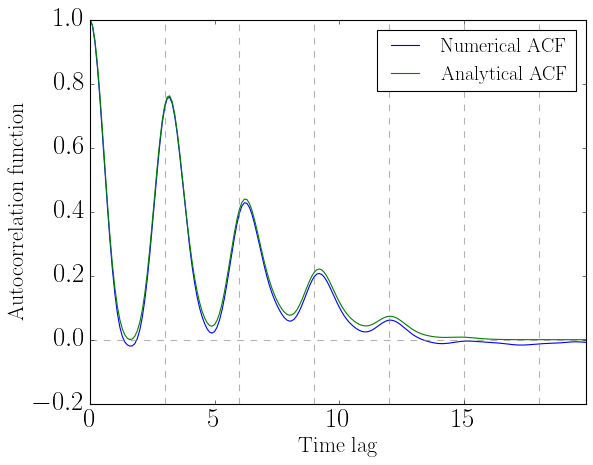

In [13]:
plt.plot(tlags, acf_num, label="Numerical ACF")
plt.plot(tlags, acf_ana, label="Analytical ACF")
for ii in range(1, 10):
    plt.axvline(ii * theta_full["peq"], color='gray', ls='--', alpha=0.6)
plt.axhline(0, color='gray', ls='--', alpha=0.6)
plt.xlabel("Time lag", fontsize=20)
plt.ylabel("Autocorrelation function", fontsize=20)
plt.legend(loc="upper right", fontsize=18)
plt.xlim(min(tlags), max(tlags))
plt.show()